# Task 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# task 1
initialReport = {}
dataSet = pd.read_csv("dataSet.csv")
print("File loaded")
print(dataSet)
print("\n" * 5)
print("INFO:")
dataSet.info()
print("\n" * 5)
print("DESCRIBE:")
print(dataSet.describe())
print("\n" * 5)
print("SHAPE:")
initialReport["shape"] = dataSet.shape
print(initialReport["shape"])
print("\n" * 5)
print("TYPES:")
initialReport["dtypes"] = dataSet.dtypes
print(initialReport["dtypes"])
amountOfNaN = dataSet.isna().sum().sum()
amountOfDublicates = dataSet.duplicated(keep=False).sum()
amountOfUnique = dataSet.nunique()
top5 = dataSet.select_dtypes(include=["string", "object"]).value_counts().head()
print("INITIAL REPORT")
initialReport.update({"missing": amountOfNaN, "duplicates": amountOfDublicates})
print(initialReport)

File loaded
                            id                              time  year  month  \
0        cent19000105190000000         1900-01-05 19:00:00+00:00  1900      1   
1        cent19000111090700000         1900-01-11 09:07:00+00:00  1900      1   
2        cent19000120063300000         1900-01-20 06:33:00+00:00  1900      1   
3        cent19000131192200000         1900-01-31 19:22:00+00:00  1900      1   
4                     ushis388         1900-04-09 14:00:00+00:00  1900      4   
...                        ...                               ...   ...    ...   
1054984             us6000snkl  2026-04-08 21:20:13.746000+00:00  2026      4   
1054985             us6000snkm  2026-04-08 21:29:09.128000+00:00  2026      4   
1054986             us6000snkz  2026-04-08 22:13:51.402000+00:00  2026      4   
1054987             pr71513138  2026-04-08 22:39:53.740000+00:00  2026      4   
1054988             us6000snlc  2026-04-08 23:23:04.196000+00:00  2026      4   

         day_of

# Task 2

In [2]:
dataSetClean = dataSet.copy()
dataSetClean.fillna(dataSetClean.median(numeric_only=True), inplace=True)
afterNumFill = amountOfNaN - dataSetClean.isna().sum().sum()
amountOfNaN = dataSetClean.isna().sum().sum()
datesCol = ["time", "year", "month", "day_of_year", "hour"]
dataSetClean[datesCol] = dataSetClean[datesCol].replace("", np.nan)
dataSetClean.dropna(subset=["time"], inplace=True)
afterTimeDelete = amountOfNaN - dataSetClean.isna().sum().sum()
amountOfNaN = dataSetClean.isna().sum().sum()
dataSetClean.fillna(
    dataSetClean.mode().iloc[0], inplace=True
)  # заполнеят все пустые места модой
afterStringFill = amountOfNaN - dataSetClean.isna().sum().sum()
amountOfNaN = dataSetClean.isna().sum().sum()
dataSetClean.drop_duplicates(keep="first")
dataSetClean.reset_index(drop=True, inplace=True)
print("INFO:\nDataSet before cleaning:\n")
dataSet.info()
print("DataSet after cleaning:\n")
dataSetClean.info()


INFO:
DataSet before cleaning:

<class 'pandas.DataFrame'>
RangeIndex: 1054989 entries, 0 to 1054988
Data columns (total 23 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   id              1054989 non-null  str    
 1   time            1054989 non-null  str    
 2   year            1054989 non-null  int64  
 3   month           1054989 non-null  int64  
 4   day_of_year     1054989 non-null  int64  
 5   hour            1054989 non-null  int64  
 6   latitude        1054989 non-null  float64
 7   longitude       1054989 non-null  float64
 8   depth           1054096 non-null  float64
 9   mag             1054989 non-null  float64
 10  magType         1054905 non-null  str    
 11  place           1054989 non-null  str    
 12  type            1054989 non-null  str    
 13  tsunami         1054989 non-null  int64  
 14  mag_category    1054989 non-null  str    
 15  depth_category  1054090 non-null  str    
 16  nst            

# Task 3
добавляет boolean колоннку isHumanMade если землетрисение было вызванно человеком

In [3]:
dataSetClean["isHumanMade"] = (
    True if "explosion" in dataSetClean["type"].str.lower() else False
)

добавляетс колонку с приблизительной выделенной энергией

In [4]:
dataSetClean["energyEstimate"] = 10 ** (1.5 * dataSetClean["mag"] + 4.8)
dataSetClean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1054989 entries, 0 to 1054988
Data columns (total 25 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   id              1054989 non-null  str    
 1   time            1054989 non-null  str    
 2   year            1054989 non-null  int64  
 3   month           1054989 non-null  int64  
 4   day_of_year     1054989 non-null  int64  
 5   hour            1054989 non-null  int64  
 6   latitude        1054989 non-null  float64
 7   longitude       1054989 non-null  float64
 8   depth           1054989 non-null  float64
 9   mag             1054989 non-null  float64
 10  magType         1054989 non-null  str    
 11  place           1054989 non-null  str    
 12  type            1054989 non-null  str    
 13  tsunami         1054989 non-null  int64  
 14  mag_category    1054989 non-null  str    
 15  depth_category  1054989 non-null  str    
 16  nst             1054989 non-null  float64
 17  

добавляет время суток в которое произошло событие

In [5]:
dataSetClean["part_of_day"] = pd.cut(
    dataSetClean["hour"],
    bins=[0, 6, 12, 18, 24],
    labels=["Night", "Morning", "Afternoon", "Evening"],
    right=False,
)
dataSetClean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1054989 entries, 0 to 1054988
Data columns (total 26 columns):
 #   Column          Non-Null Count    Dtype   
---  ------          --------------    -----   
 0   id              1054989 non-null  str     
 1   time            1054989 non-null  str     
 2   year            1054989 non-null  int64   
 3   month           1054989 non-null  int64   
 4   day_of_year     1054989 non-null  int64   
 5   hour            1054989 non-null  int64   
 6   latitude        1054989 non-null  float64 
 7   longitude       1054989 non-null  float64 
 8   depth           1054989 non-null  float64 
 9   mag             1054989 non-null  float64 
 10  magType         1054989 non-null  str     
 11  place           1054989 non-null  str     
 12  type            1054989 non-null  str     
 13  tsunami         1054989 non-null  int64   
 14  mag_category    1054989 non-null  str     
 15  depth_category  1054989 non-null  str     
 16  nst             1054989 non-n

# Task 4

Finished sorting


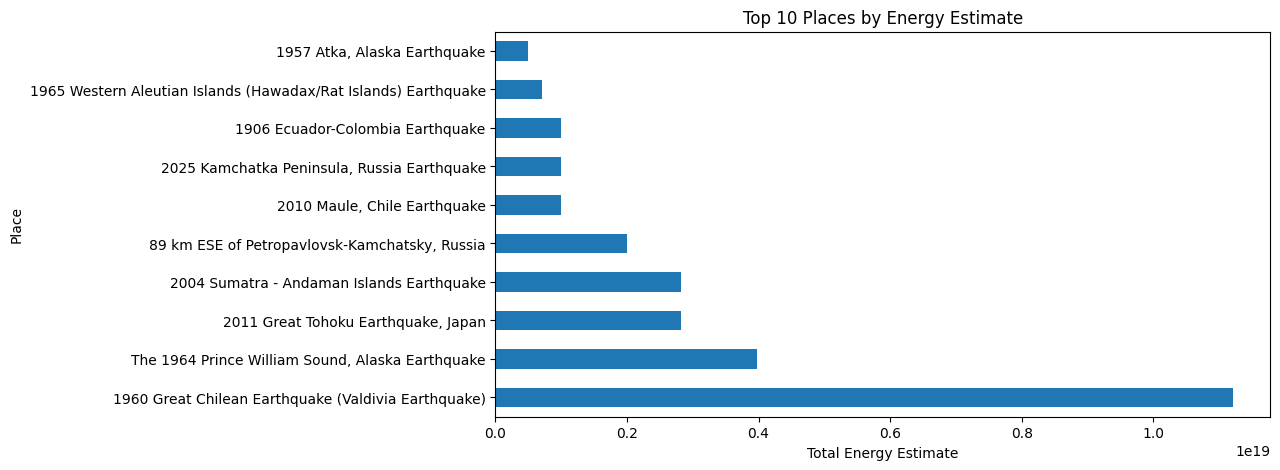

In [6]:
top10 = dataSetClean.groupby("place")["energyEstimate"].sum().sort_values(ascending=False).head(10)
print("Finished sorting")

top10.plot(kind="barh", figsize=(10,5))
plt.title("Top 10 Places by Energy Estimate")
plt.xlabel("Total Energy Estimate")
plt.ylabel("Place")
plt.show()

In [7]:
depthAnalysis = (
    dataSetClean.groupby("depth_category")
      .agg(
          total_mag=("mag", "sum"),
          avg_mag=("mag", "mean"),
          unique_events=("id", "nunique")
      )
)
dataSetClean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1054989 entries, 0 to 1054988
Data columns (total 26 columns):
 #   Column          Non-Null Count    Dtype   
---  ------          --------------    -----   
 0   id              1054989 non-null  str     
 1   time            1054989 non-null  str     
 2   year            1054989 non-null  int64   
 3   month           1054989 non-null  int64   
 4   day_of_year     1054989 non-null  int64   
 5   hour            1054989 non-null  int64   
 6   latitude        1054989 non-null  float64 
 7   longitude       1054989 non-null  float64 
 8   depth           1054989 non-null  float64 
 9   mag             1054989 non-null  float64 
 10  magType         1054989 non-null  str     
 11  place           1054989 non-null  str     
 12  type            1054989 non-null  str     
 13  tsunami         1054989 non-null  int64   
 14  mag_category    1054989 non-null  str     
 15  depth_category  1054989 non-null  str     
 16  nst             1054989 non-n

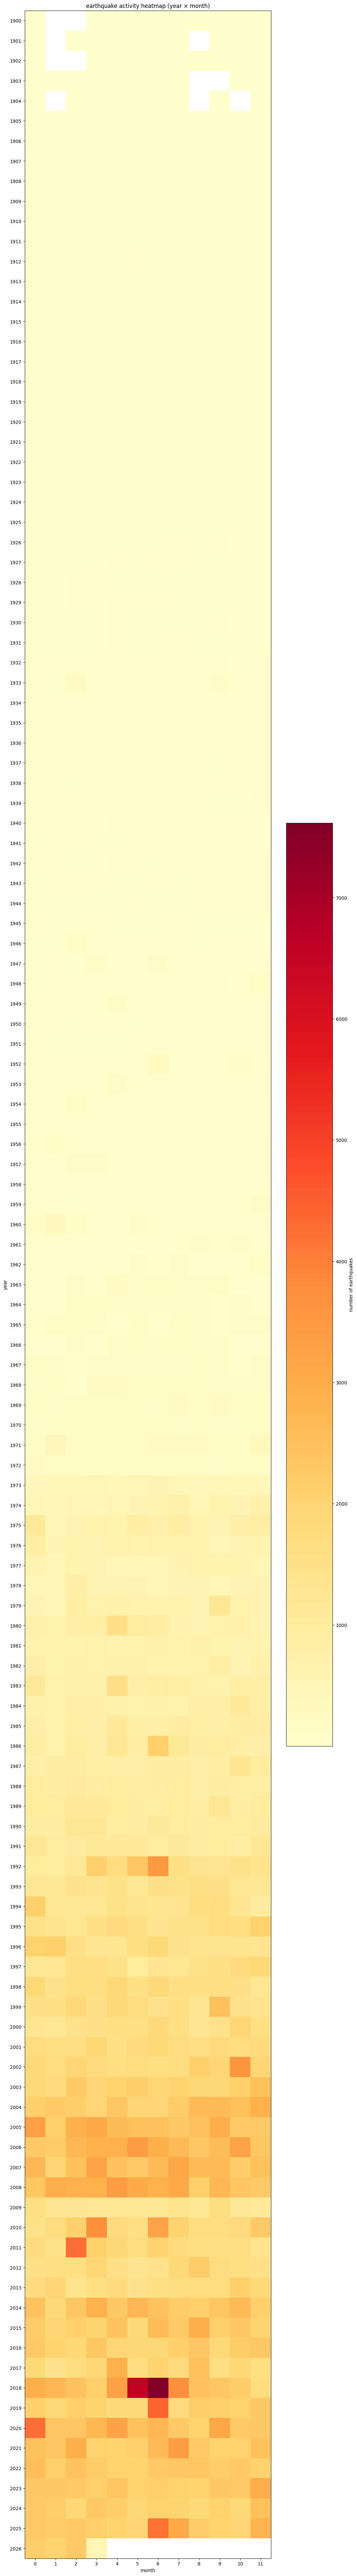

In [16]:
heatmapData = (
    dataSetClean.groupby(["year", "month"])
      .agg(eventCount=("id", "count"))
      .reset_index()
)
pivot = heatmapData.pivot(index="year", columns="month", values="eventCount")
plt.figure(figsize=(12, 100))
plt.imshow(pivot, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="number of earthquakes")
plt.xticks(
    ticks=range(12),
    labels=range(12),
    rotation=0
)
plt.yticks(
    ticks=range(len(pivot.index)),
    labels=pivot.index
)
plt.title("earthquake activity heatmap (year × month)")
plt.xlabel("month")
plt.ylabel("year")

plt.show()

In [9]:
multiGroup = (
    dataSetClean.groupby(["mag_category", "depth_category"])
      .agg(avgMag=("mag", "mean"),
           count=("id", "count"))
)

multiGroup

avgMag   count
mag_category   depth_category                           
Great (7-8)    Deep (300-700km)         7.344706     102
               Intermediate (70-300km)  7.373129     147
               Shallow (0-70km)         7.366394    1040
Light (3-4)    Deep (300-700km)         3.863759    4884
               Intermediate (70-300km)  3.628166   33836
               Shallow (0-70km)         3.482824  208721
Major (6-7)    Deep (300-700km)         6.437293     447
               Intermediate (70-300km)  6.380448     915
               Shallow (0-70km)         6.353282    9917
Massive (8+)   Deep (300-700km)         8.233333       3
               Intermediate (70-300km)  8.160000       5
               Shallow (0-70km)         8.319722      72
Minor (2.5-3)  Deep (300-700km)         2.945455      22
               Intermediate (70-300km)  2.721165   24061
               Shallow (0-70km)         2.720425  275470
Moderate (4-5) Deep (300-700km)         4.426514   28325
               Intermediate (70-300km)  4.457911   86575
               Shallow (0-70km)         4.502247  306624
Strong (5-6)   Deep (300-700km)         5.403445    3103
               Intermediate (70-300km)  5.356779   10382
               Shallow (0-70km)         5.401857   60338

# Task 5

In [10]:
newTable = dataSetClean["id"]
newTable = newTable.to_frame()
newTable["casualties"] = np.random.randint(0, 1000, size=len(newTable))
newTable["typeOfAreaAffected"] = np.random.choice(["Urban", "Rural", "Industrial", "Agricultural", "Other"], size=len(newTable))
newTable.to_csv("newTable.csv")
newTable.info()
dataSetClean.info()
dataSetMerged = dataSetClean.merge(newTable, on="id", how="left")
dataSetMerged.info()

<class 'pandas.DataFrame'>
RangeIndex: 1054989 entries, 0 to 1054988
Data columns (total 3 columns):
 #   Column              Non-Null Count    Dtype
---  ------              --------------    -----
 0   id                  1054989 non-null  str  
 1   casualties          1054989 non-null  int64
 2   typeOfAreaAffected  1054989 non-null  str  
dtypes: int64(1), str(2)
memory usage: 24.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 1054989 entries, 0 to 1054988
Data columns (total 26 columns):
 #   Column          Non-Null Count    Dtype   
---  ------          --------------    -----   
 0   id              1054989 non-null  str     
 1   time            1054989 non-null  str     
 2   year            1054989 non-null  int64   
 3   month           1054989 non-null  int64   
 4   day_of_year     1054989 non-null  int64   
 5   hour            1054989 non-null  int64   
 6   latitude        1054989 non-null  float64 
 7   longitude       1054989 non-null  float64 
 8   depth           1054

                     totalEnergy     avgEnergy  uniqueEvents
typeOfAreaAffected                                          
Agricultural        2.110490e+19  9.988217e+13        211298
Industrial          1.092365e+19  5.167630e+13        211386
Other               8.554726e+18  4.061726e+13        210618
Rural               6.908056e+18  3.279867e+13        210620
Urban               9.808147e+18  4.646935e+13        211067


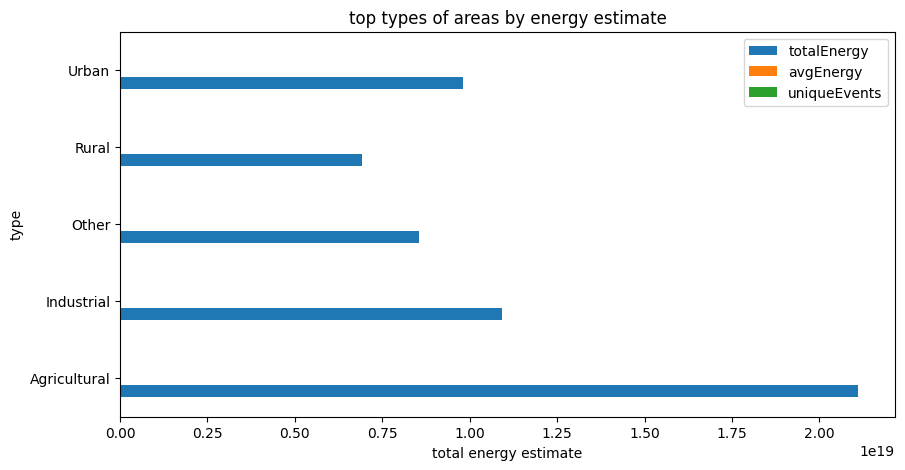

In [11]:

depthAnalysisNew = (
    dataSetMerged.groupby("typeOfAreaAffected")
      .agg(
          totalEnergy=("energyEstimate", "sum"),
          avgEnergy=("energyEstimate", "mean"),
          uniqueEvents=("id", "nunique")
      )
)
print(depthAnalysisNew)
depthAnalysisNew.plot(kind="barh", figsize=(10,5))
plt.title("top types of areas by energy estimate")
plt.xlabel("total energy estimate")
plt.ylabel("type")
plt.show()

# Task 6

In [12]:
pivotTable1 = dataSetMerged.pivot_table("casualties","mag_category", "typeOfAreaAffected", margins=True)
print(pivotTable1)
pivotTable = dataSetMerged.pivot_table("casualties","mag_category", "typeOfAreaAffected")
pivot = pivotTable.stack().reset_index()
print(pivot)
pivot.columns = [
    "mag_category",
    "typeOfAreaAffected",
    "casualties"
]

print(pivot)

typeOfAreaAffected  Agricultural  Industrial       Other       Rural  \
mag_category                                                           
Great (7-8)           498.531496  498.740072  508.647773  481.829457   
Light (3-4)           499.052791  501.217878  501.287347  499.223902   
Major (6-7)           501.982198  513.920305  502.318692  505.038247   
Massive (8+)          346.157895  501.800000  503.800000  365.230769   
Minor (2.5-3)         498.230889  499.321319  499.676355  499.959258   
Moderate (4-5)        499.687379  498.941250  497.489147  499.167331   
Strong (5-6)          496.807108  500.250218  499.944101  500.150367   
All                   498.932650  499.842388  499.234956  499.508936   

typeOfAreaAffected       Urban         All  
mag_category                                
Great (7-8)         478.940711  493.326610  
Light (3-4)         500.053098  500.168658  
Major (6-7)         509.302357  506.605107  
Massive (8+)        471.555556  436.087500  
Minor (2.

# Task 7

In [13]:
dataSetMerged["estEnergyInMagCat"] = dataSetMerged.groupby("mag_category")["energyEstimate"].transform(lambda x: x/x.sum())
dataSetMerged["rangInMagCat"] = dataSetMerged.groupby('mag_category')['energyEstimate'].rank(method='dense', ascending=False)

# Task 8
dumb variant

In [14]:
%%timeit
dataSetLoop = dataSetMerged.copy()

dataSetLoop['unique_types_in_group'] = 0

for category in dataSetLoop['mag_category'].unique():
    mask = dataSetLoop['mag_category'] == category
    nunique = 0
    checked = []
    for value in dataSetLoop.loc[mask, 'type']:
        flag = True
        for pointer in checked:
            if checked == value:
                flag = False
                break
        if flag: nunique += 1
    dataSetLoop.loc[mask, 'unique_types_in_group'] = nunique


815 ms ± 1.37 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


vectorized variant

In [15]:
%%timeit

dataSetVectorized = dataSetMerged.copy()

dataSetVectorized['unique_types_in_group'] = (
    dataSetVectorized.groupby('mag_category')['type']
                 .transform('nunique')
)

216 ms ± 272 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
